<a href="https://colab.research.google.com/github/obeabi/ProjectPortfolio/blob/master/ASX_DeepDive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install --upgrade yfinance
!pip install finnhub-python
!pip install hurst -q
!pip install ta

In [9]:
import yfinance as yf
print(yf.__version__)
import pandas as pd
#import pandas_ta as ta
import numpy as np
import time
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import linregress
import matplotlib.dates as mdates

import ta
print("Libraries Installed!")

1.7.0
Libraries Installed!


# Monthly Win-rate for ASX200

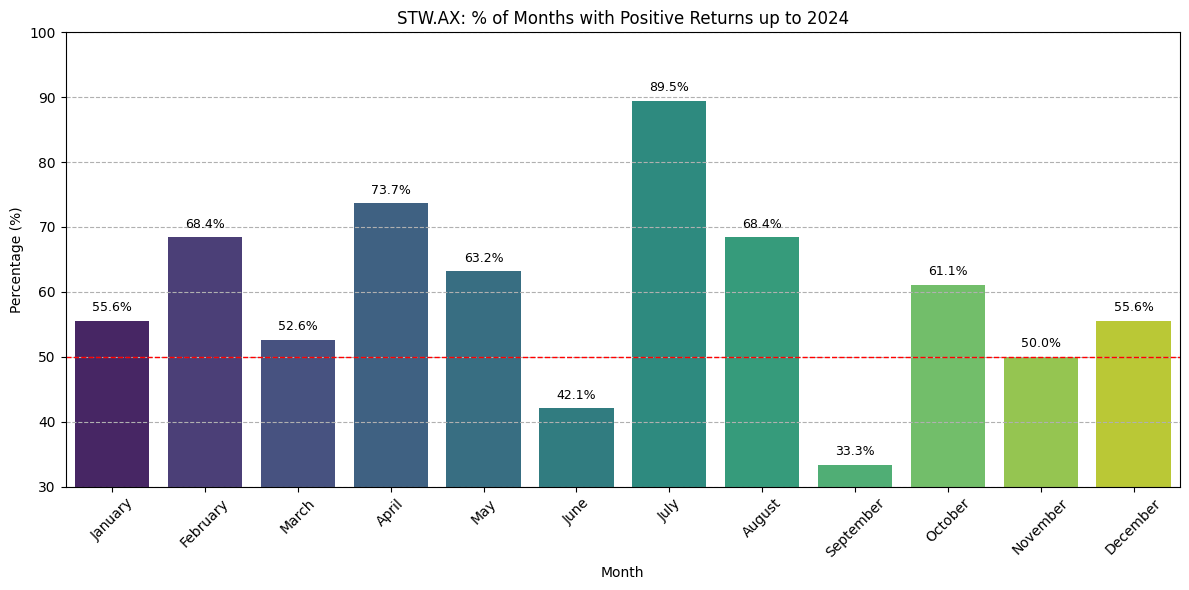

In [13]:
# Step 1: Download SPY historical data
ticker= "STW.AX"
spy = yf.download(ticker, start="1993-01-01", end="2026-08-31", progress=False,auto_adjust=False)

# Step 2: Resample to monthly data and calculate returns
spy_monthly = spy['Close'].resample('ME').last()
monthly_returns = spy_monthly.pct_change().dropna()


# Step 3: Extract month names and whether return was positive
monthly_returns.columns = ['Return']
monthly_returns_df = monthly_returns.copy()
monthly_returns_df['Month'] = monthly_returns_df.index.month_name()
monthly_returns_df['Positive'] = monthly_returns_df['Return'] > 0


# Step 4: Group by month and calculate percent positive
positive_rate = (
    monthly_returns_df.groupby('Month')['Positive']
    .mean()
    .rename("Percent Positive")
    .mul(100)
    .reset_index()
)

# Step 5: Order months chronologically
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
positive_rate['Month'] = pd.Categorical(positive_rate['Month'], categories=month_order, ordered=True)
positive_rate = positive_rate.sort_values('Month')

# Step 6: Plot using Seaborn
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=positive_rate,
    x='Month',
    y='Percent Positive',
    hue='Month',
    palette='viridis',
    legend=False
)

# Annotate each bar with the exact value
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )
# Add horizontal reference line at 50%
plt.axhline(50, color='red', linestyle='--', linewidth=1, label='Neutral (50%)')
plt.xticks(rotation=45)
plt.title("{}: % of Months with Positive Returns up to 2024".format(ticker))
plt.ylabel("Percentage (%)")
plt.ylim(30, 100)  # Set scale from 30% to 100%
plt.grid(axis='y', linestyle='--', alpha=1.)
plt.tight_layout()
plt.show()


#monthly_returns_df.head()

## Days of Week

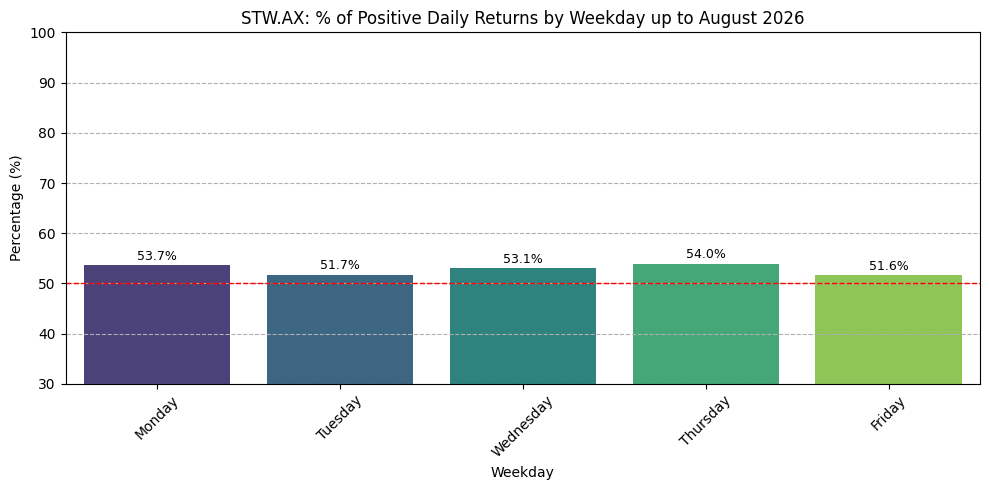

In [14]:
# Step 1: Download SPY historical data
spy = yf.download(ticker, start="1993-01-01", end="2026-08-31", progress=False,auto_adjust=False)

# Step 2: calculate daily returns
spy['Return'] = spy['Close'].pct_change()
spy = spy.dropna()


# Step 3: Add weekday column
spy['Weekday'] = spy.index.day_name()
spy['Positive'] = spy['Return'] > 0



# Step 4: Group by weekday and calculate percentage of positive returns
positive_rate_weekday = (
    spy.groupby('Weekday')['Positive']
    .mean()
    .rename("Percent Positive")
    .mul(100)
    .reset_index()
)

# Ensure days are in Monday–Friday order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
positive_rate_weekday['Weekday'] = pd.Categorical(
    positive_rate_weekday['Weekday'], categories=weekday_order, ordered=True
)
positive_rate_weekday = positive_rate_weekday.sort_values('Weekday')

# Step 5: Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=positive_rate_weekday,
    x='Weekday',
    y='Percent Positive',
    hue='Weekday',
    palette='viridis',
    legend=False
)

# Annotate each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Add horizontal reference line at 50%
plt.axhline(50, color='red', linestyle='--', linewidth=1, label='Neutral (50%)')

# Customize axes and layout
plt.title("{}: % of Positive Daily Returns by Weekday up to August 2026".format(ticker))
plt.xticks(rotation=45)
plt.ylabel("Percentage (%)")
plt.ylim(30, 100)  # Set scale from 30% to 100%
plt.grid(axis='y', linestyle='--', alpha=1.)
plt.tight_layout()
plt.show()

#spy.head()

# 3-Year Presidential Cycle

[*********************100%***********************]  1 of 1 completed


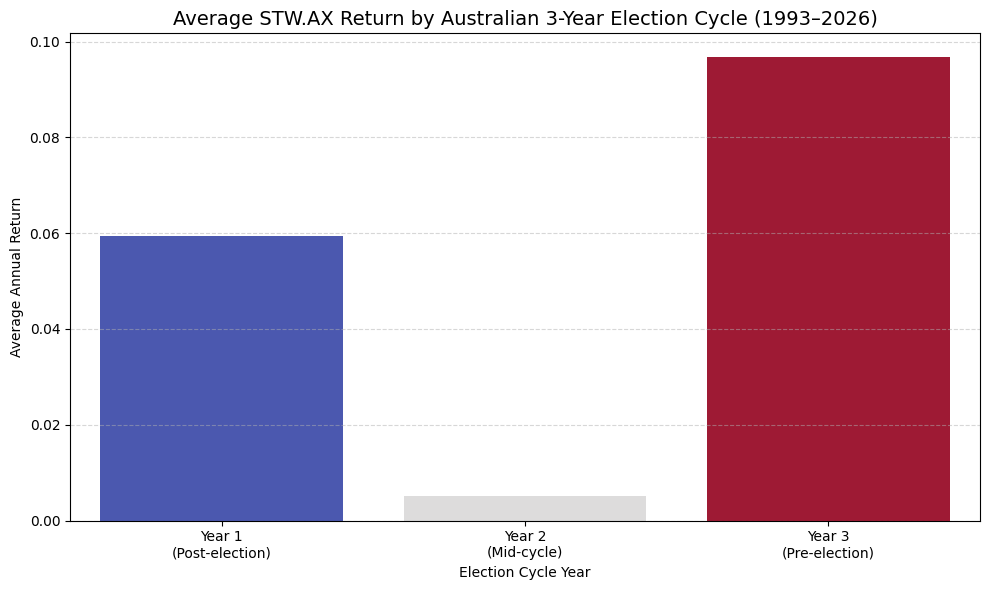

In [15]:

spy = yf.download(ticker, start="1900-01-01", end="2026-08-31", interval="1mo", auto_adjust=False)
spy['Year'] = spy.index.year

# Step 2: Extract year-end closing prices
yearly_close = spy.groupby('Year')['Close'].last()

# Step 3: Calculate annual returns
yearly_close['Return'] = yearly_close['Close'].pct_change()
yearly_close = yearly_close.dropna().reset_index()

# Actual Australian federal election years (House of Representatives)
# Source: AEC (Australian Electoral Commission)
election_years = [
    1993, 1996, 1998, 2001, 2004, 2007,
    2010, 2013, 2016, 2019, 2022, 2025
]

def get_aus_cycle_year(year):
    """
    Assigns Australian 3-year election cycle year based on actual election dates.

    Cycle Year 1 = Post-election year
    Cycle Year 2 = Mid-cycle
    Cycle Year 3 = Pre-election year
    """
    # Find the most recent election year <= current year
    last_election = max([e for e in election_years if e <= year])

    # Distance from last election
    diff = year - last_election

    # Cycle year mapping
    if diff == 0:
        return 1  # Election year itself → treat as Cycle Year 1
    elif diff == 1:
        return 2  # Mid-cycle
    elif diff == 2:
        return 3  # Pre-election
    else:
        # If diff > 2, it means election was delayed or early
        # Wrap into 3-year cycle
        return ((diff % 3) + 1)

yearly_close['CycleYear'] = yearly_close['Year'].apply(get_aus_cycle_year)

# Step 5: Compute average return by cycle year
cycle_stats = yearly_close.groupby('CycleYear')['Return'].agg(['mean', 'median', 'std', 'count']).reset_index()


# Step 6: Plot the result
plt.figure(figsize=(10, 6))
sns.barplot(
    x='CycleYear',
    y='mean',
    data=cycle_stats,
    hue='CycleYear',            # Assign hue explicitly
    palette='coolwarm',         # Still use the same color palette
    legend=False                # Hide redundant legend
)

plt.title('Average {} Return by Australian 3-Year Election Cycle (1993–2026)'.format(ticker), fontsize=14)
plt.xlabel('Election Cycle Year')
plt.ylabel('Average Annual Return')

# IMPORTANT: 3-year cycle → labels for 1, 2, 3
plt.xticks(
    [0, 1, 2],
    [
        'Year 1\n(Post-election)',
        'Year 2\n(Mid-cycle)',
        'Year 3\n(Pre-election)'
    ]
)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
